# Image Processing Cheatsheet
> Building blocks of Computer Vision — from pixels to object detection

## Table of Contents
1. [Image Fundamentals](#fundamentals) — pixels, channels, color spaces, histograms
2. [Image Filtering](#filtering) — convolution, Gaussian blur, sharpening
3. [Edge Detection](#edges) — Sobel, Prewitt, Laplacian, Canny pipeline
4. [Morphological Operations](#morphology) — erosion, dilation, opening, closing
5. [Image Segmentation](#segmentation) — thresholding (Otsu), k-means, watershed
6. [Feature Detection & Matching](#features) — Harris corners, ORB overview, matching
7. [Object Detection Fundamentals](#detection) — sliding window, IoU, NMS, anchors, YOLO
8. [Video Processing](#video) — optical flow (Lucas-Kanade), background subtraction

---
*All code uses only NumPy + Matplotlib — no OpenCV or PIL required.*

<a name="fundamentals"></a>
## 1. Image Fundamentals

### Pixels and Color Channels

A digital image is a 2-D array (or 3-D for color) of **pixel** intensities:

| Format | Shape | Range |
|--------|-------|-------|
| Grayscale | $(H, W)$ | $[0, 255]$ |
| RGB | $(H, W, 3)$ | $[0, 255]$ per channel |
| Float | $(H, W, C)$ | $[0, 1]$ |

### Color Spaces

**RGB → Grayscale** (luminance):
$$I = 0.299\,R + 0.587\,G + 0.114\,B$$

**RGB → HSV** (Hue, Saturation, Value):
$$V = \max(R,G,B), \quad S = \frac{V - \min(R,G,B)}{V}, \quad H \in [0°, 360°]$$

HSV is useful for color-based segmentation because hue is invariant to brightness.

---

### Histogram
The histogram $h(v)$ counts how many pixels have intensity $v$:
$$h(v) = \sum_{i,j} \mathbf{1}[I(i,j) = v], \quad v \in [0,255]$$

**Histogram Equalisation** stretches the CDF to be uniform — improves contrast:
$$I_{\text{eq}}(i,j) = \lfloor (L-1)\,\text{CDF}(I(i,j)) \rfloor$$

where $\text{CDF}(v) = \frac{1}{HW}\sum_{u \leq v} h(u)$.

C:\Users\Javad\AppData\Local\Temp\ipykernel_6656\4260442831.py:32: RuntimeWarning: invalid value encountered in divide
  S = np.where(Cmax != 0, delta / Cmax, 0)


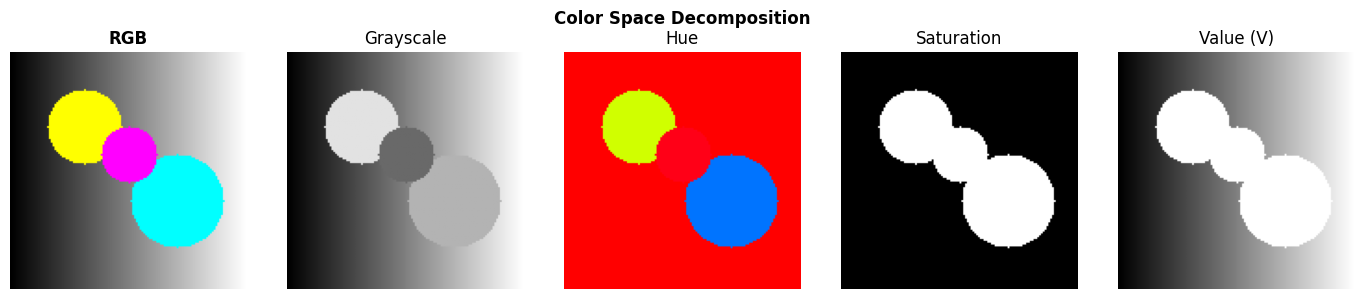

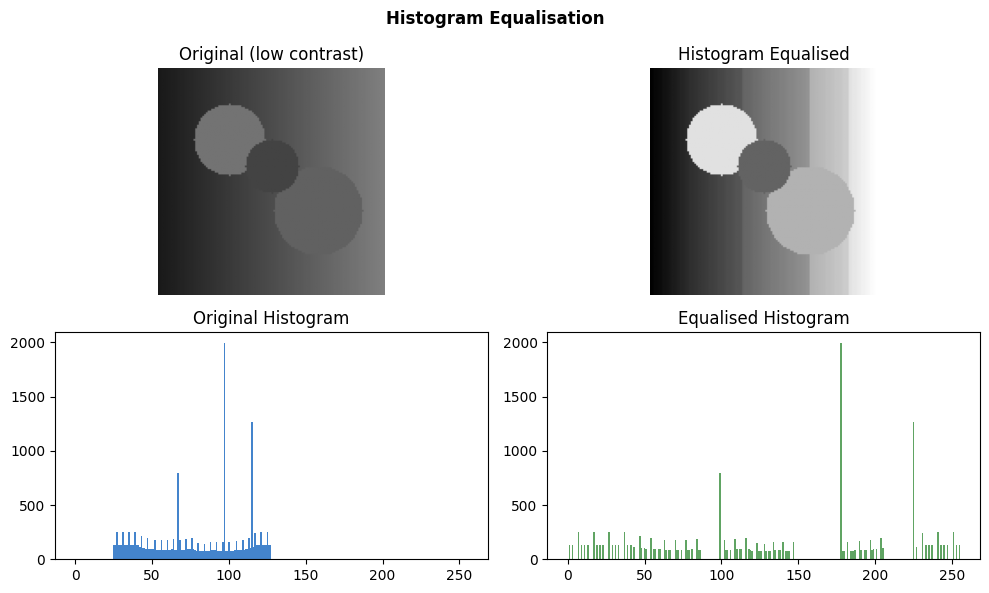

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# ── Synthesise a test image (gradient + circles) ──────────────────────────────
H, W = 128, 128

def make_test_image():
    img = np.zeros((H, W, 3), dtype=np.float32)
    # Gradient background
    for c, (r,g,b) in enumerate([(1,0,0),(0,1,0),(0,0,1)]):
        img[:,:,c] = np.linspace(0, 1, W) * [r,g,b][c]
    # Add circles
    Y, X = np.ogrid[:H, :W]
    for (cy,cx,cr,color) in [(40,40,20,[1,1,0]),(80,90,25,[0,1,1]),(55,64,15,[1,0,1])]:
        mask = (X-cx)**2 + (Y-cy)**2 <= cr**2
        img[mask] = color
    return np.clip(img, 0, 1)

img_rgb = make_test_image()

# ── RGB → Grayscale ───────────────────────────────────────────────────────────
def rgb2gray(img):
    return 0.299*img[:,:,0] + 0.587*img[:,:,1] + 0.114*img[:,:,2]

def rgb2hsv(img):
    """img: float [0,1] RGB → HSV"""
    R, G, B = img[:,:,0], img[:,:,1], img[:,:,2]
    Cmax = np.max(img, axis=2); Cmin = np.min(img, axis=2); delta = Cmax - Cmin
    V = Cmax
    S = np.where(Cmax != 0, delta / Cmax, 0)
    H = np.zeros_like(R)
    mask_r = (Cmax == R) & (delta != 0)
    mask_g = (Cmax == G) & (delta != 0)
    mask_b = (Cmax == B) & (delta != 0)
    H[mask_r] = (60 * ((G[mask_r]-B[mask_r]) / delta[mask_r]) % 360)
    H[mask_g] = (60 * ((B[mask_g]-R[mask_g]) / delta[mask_g]) + 120)
    H[mask_b] = (60 * ((R[mask_b]-G[mask_b]) / delta[mask_b]) + 240)
    return np.stack([H/360, S, V], axis=2)

gray = rgb2gray(img_rgb)
hsv  = rgb2hsv(img_rgb)

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
axes[0].imshow(img_rgb); axes[0].set_title("RGB", fontweight="bold")
axes[1].imshow(gray, cmap="gray"); axes[1].set_title("Grayscale")
axes[2].imshow(hsv[:,:,0], cmap="hsv"); axes[2].set_title("Hue")
axes[3].imshow(hsv[:,:,1], cmap="gray"); axes[3].set_title("Saturation")
axes[4].imshow(hsv[:,:,2], cmap="gray"); axes[4].set_title("Value (V)")
for ax in axes: ax.axis("off")
plt.suptitle("Color Space Decomposition", fontweight="bold"); plt.tight_layout(); plt.show()

# ── Histogram + Equalisation ─────────────────────────────────────────────────
# Create a low-contrast image
dark = (gray * 0.4 + 0.1).clip(0, 1)
gray8 = (dark * 255).astype(np.uint8)

hist, bins = np.histogram(gray8.ravel(), bins=256, range=(0,256))
cdf = hist.cumsum()
cdf_norm = cdf / cdf[-1]
equalized = np.floor(255 * cdf_norm[gray8]).astype(np.uint8)

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes[0,0].imshow(gray8, cmap="gray", vmin=0, vmax=255); axes[0,0].set_title("Original (low contrast)")
axes[0,1].imshow(equalized, cmap="gray", vmin=0, vmax=255); axes[0,1].set_title("Histogram Equalised")
axes[1,0].bar(bins[:-1], hist, width=1, color="#1565C0", alpha=0.8); axes[1,0].set_title("Original Histogram")
axes[1,1].bar(range(256), np.histogram(equalized.ravel(),256,(0,256))[0],
              width=1, color="#388E3C", alpha=0.8); axes[1,1].set_title("Equalised Histogram")
for ax in axes[0]: ax.axis("off")
plt.suptitle("Histogram Equalisation", fontweight="bold"); plt.tight_layout(); plt.show()

<a name="filtering"></a>
## 2. Image Filtering

### 2-D Convolution
Filtering replaces each pixel with a weighted sum of its neighbourhood, defined by a **kernel** $K$ of size $k \times k$:

$$(I * K)(i,j) = \sum_{m=-a}^{a}\sum_{n=-a}^{a} I(i+m,\,j+n)\,K(m,n), \quad a = \lfloor k/2 \rfloor$$

The output is called the **feature map** or **filtered image**.

---

### Common Kernels

| Filter | Kernel | Effect |
|--------|--------|--------|
| Box blur | $\frac{1}{9}\mathbf{1}_{3\times3}$ | Uniform smoothing |
| Gaussian | $\frac{1}{16}\begin{bmatrix}1&2&1\\2&4&2\\1&2&1\end{bmatrix}$ | Smooth + preserve edges better |
| Sharpening | $\begin{bmatrix}0&-1&0\\-1&5&-1\\0&-1&0\end{bmatrix}$ | Enhance high frequencies |
| Laplacian | $\begin{bmatrix}0&1&0\\1&-4&1\\0&1&0\end{bmatrix}$ | Detect edges (2nd derivative) |

---

### Gaussian Blur
Gaussian kernel with standard deviation $\sigma$:

$$G(x,y) = \frac{1}{2\pi\sigma^2}\exp\!\left(-\frac{x^2+y^2}{2\sigma^2}\right)$$

Key properties:
- Larger $\sigma$ → more blurring
- Separable: $G(x,y)=G(x)\cdot G(y)$ → two 1-D passes (faster)
- Reduces noise before edge detection

---

### Unsharp Masking
Sharpen by adding back the high-frequency content:
$$I_{\text{sharp}} = I + \alpha\,(I - I_{\text{blur}}) = (1+\alpha)\,I - \alpha\,I_{\text{blur}}$$

Gaussian kernel (5×5, σ=1.5):
[[0.0144 0.0281 0.0351 0.0281 0.0144]
 [0.0281 0.0547 0.0683 0.0547 0.0281]
 [0.0351 0.0683 0.0853 0.0683 0.0351]
 [0.0281 0.0547 0.0683 0.0547 0.0281]
 [0.0144 0.0281 0.0351 0.0281 0.0144]]


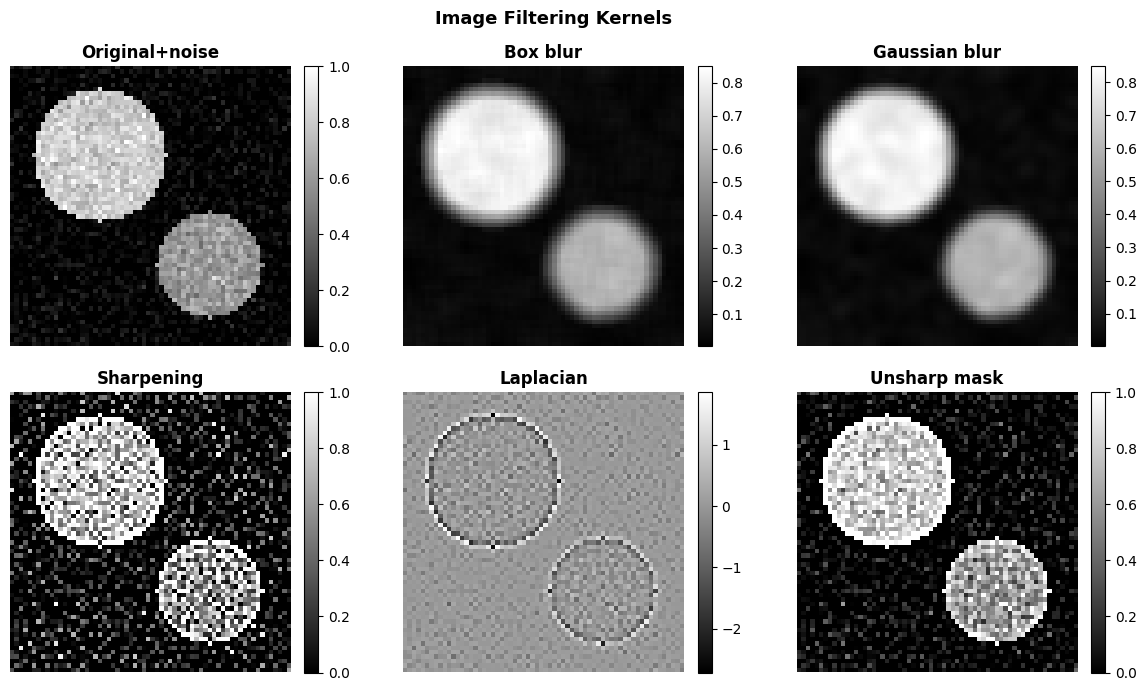

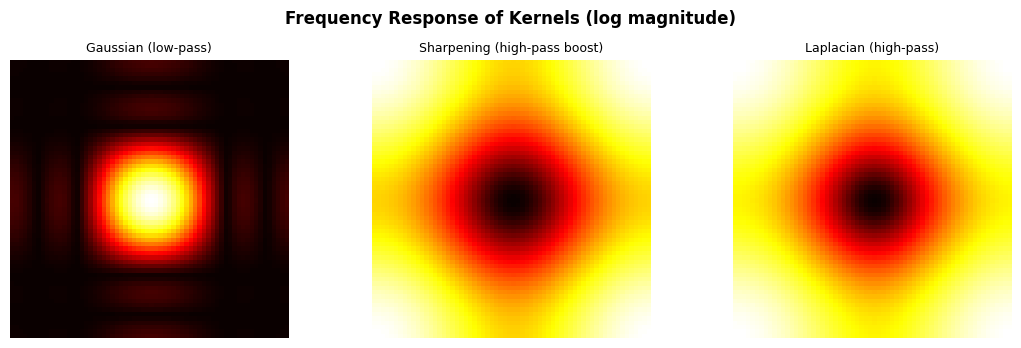

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ── 2-D convolution (no padding) ──────────────────────────────────────────────
def conv2d(image, kernel):
    """Apply 2-D convolution. image: (H,W), kernel: (kH,kW)."""
    H, W = image.shape
    kH, kW = kernel.shape
    pH, pW = kH // 2, kW // 2
    padded = np.pad(image, ((pH,pH),(pW,pW)), mode="reflect")
    out = np.zeros_like(image, dtype=np.float32)
    for i in range(H):
        for j in range(W):
            out[i,j] = (padded[i:i+kH, j:j+kW] * kernel).sum()
    return out

def gaussian_kernel(size=5, sigma=1.0):
    ax = np.arange(-(size//2), size//2+1)
    xx, yy = np.meshgrid(ax, ax)
    k = np.exp(-(xx**2 + yy**2) / (2*sigma**2))
    return k / k.sum()

# Reference grayscale image (reuse from §1 or create fresh)
np.random.seed(0)
H, W = 64, 64
img = np.zeros((H, W))
Y, X = np.ogrid[:H, :W]
img[(X-20)**2 + (Y-20)**2 <= 15**2] = 0.8
img[(X-45)**2 + (Y-45)**2 <= 12**2] = 0.6
img += 0.08 * np.random.randn(H, W)   # add noise
img = img.clip(0, 1)

# ── Kernels ───────────────────────────────────────────────────────────────────
k_box    = np.ones((5,5)) / 25
k_gauss  = gaussian_kernel(5, sigma=1.5)
k_sharp  = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=float)
k_lapl   = np.array([[0,1,0],[1,-4,1],[0,1,0]], dtype=float)

print("Gaussian kernel (5×5, σ=1.5):")
print(np.round(k_gauss, 4))

blur_box   = conv2d(img, k_box)
blur_gauss = conv2d(img, k_gauss)
sharp      = conv2d(img, k_sharp).clip(0, 1)
laplacian  = conv2d(img, k_lapl)

# Unsharp masking
unsharp = (img + 1.5 * (img - blur_gauss)).clip(0, 1)

results = [img, blur_box, blur_gauss, sharp, laplacian, unsharp]
titles  = ["Original+noise","Box blur","Gaussian blur","Sharpening","Laplacian","Unsharp mask"]
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, r, t in zip(axes.flat, results, titles):
    im = ax.imshow(r, cmap="gray"); ax.set_title(t, fontweight="bold"); ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle("Image Filtering Kernels", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()

# ── Frequency response: visualise kernel in Fourier domain ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
kernels  = [k_gauss, k_sharp, k_lapl]
k_titles = ["Gaussian (low-pass)","Sharpening (high-pass boost)","Laplacian (high-pass)"]
for ax, k, t in zip(axes, kernels, k_titles):
    kpad = np.zeros((64,64)); s = k.shape[0]//2
    kpad[:k.shape[0],:k.shape[1]] = k
    freq = np.abs(np.fft.fftshift(np.fft.fft2(kpad)))
    ax.imshow(np.log1p(freq), cmap="hot"); ax.set_title(t, fontsize=9)
    ax.axis("off")
plt.suptitle("Frequency Response of Kernels (log magnitude)", fontweight="bold")
plt.tight_layout(); plt.show()

<a name="edges"></a>
## 3. Edge Detection

Edges are **locations of rapid intensity change** — they correspond to object boundaries.

### First-Derivative Operators

Approximate the **image gradient** with finite differences:

$$\nabla I = \left(\frac{\partial I}{\partial x}, \frac{\partial I}{\partial y}\right)$$

**Sobel kernels** (weighted central differences):
$$K_x = \begin{bmatrix}-1&0&1\\-2&0&2\\-1&0&1\end{bmatrix}, \quad
K_y = \begin{bmatrix}-1&-2&-1\\0&0&0\\1&2&1\end{bmatrix}$$

**Gradient magnitude and direction:**
$$|\nabla I| = \sqrt{G_x^2 + G_y^2}, \qquad \theta = \arctan\!\left(\frac{G_y}{G_x}\right)$$

---

### Canny Edge Detector (Pipeline)

1. **Gaussian blur** — suppress noise  
   $I_\sigma = G_\sigma * I$

2. **Gradient** — compute $|\nabla I_\sigma|$ and $\theta$ using Sobel

3. **Non-maximum suppression (NMS)** — thin edges to 1-pixel width  
   Keep pixel only if it is a local maximum along the gradient direction

4. **Double thresholding** — classify pixels:  
   - $|\nabla I| > T_\text{high}$ → **strong edge**  
   - $T_\text{low} \leq |\nabla I| \leq T_\text{high}$ → **weak edge**  
   - $|\nabla I| < T_\text{low}$ → **suppressed**

5. **Hysteresis** — keep weak edges connected to strong edges

**Why Canny is preferred:** Single-pixel edges, low false positive rate, robust to noise.

---

### Laplacian of Gaussian (LoG)
Combination of smoothing + second derivative:
$$\text{LoG}(x,y) = -\frac{1}{\pi\sigma^4}\left(1-\frac{x^2+y^2}{2\sigma^2}\right)\exp\!\left(-\frac{x^2+y^2}{2\sigma^2}\right)$$

Edges are at **zero-crossings** of LoG$*I$.

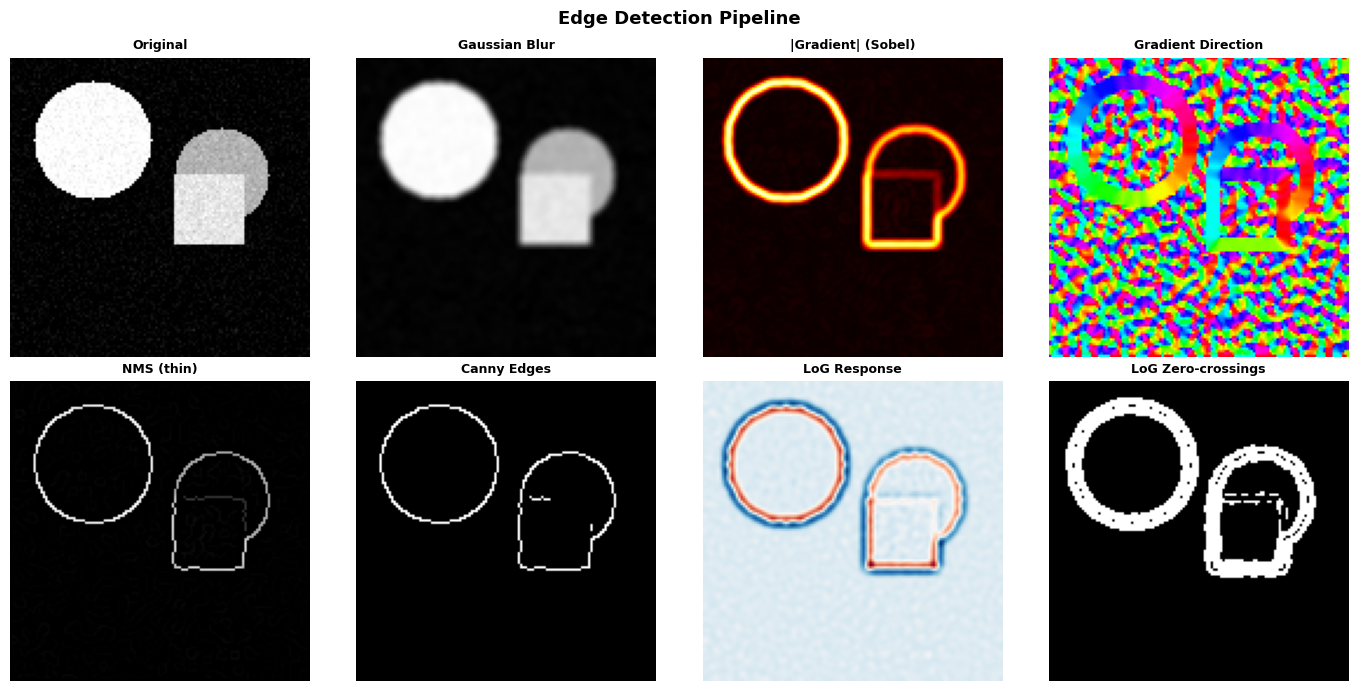

Gradient range: [0.000, 2.213]
Canny edge pixels: 375 / 16384 = 2.3%


In [3]:
import numpy as np
import matplotlib.pyplot as plt

def conv2d(image, kernel):
    H, W = image.shape; kH, kW = kernel.shape
    padded = np.pad(image, ((kH//2,kH//2),(kW//2,kW//2)), mode="reflect")
    out = np.zeros_like(image, dtype=float)
    for i in range(H):
        for j in range(W):
            out[i,j] = (padded[i:i+kH, j:j+kW] * kernel).sum()
    return out

def gaussian_kernel(size=5, sigma=1.0):
    ax = np.arange(-(size//2), size//2+1)
    xx, yy = np.meshgrid(ax, ax)
    k = np.exp(-(xx**2+yy**2)/(2*sigma**2)); return k/k.sum()

# ── Test image ────────────────────────────────────────────────────────────────
np.random.seed(1)
H, W = 128, 128
img = np.zeros((H, W))
Y, X = np.ogrid[:H, :W]
img[(X-35)**2+(Y-35)**2<=25**2] = 1.0
img[(X-90)**2+(Y-50)**2<=20**2] = 0.7
img[50:80, 70:100] = 0.9              # rectangle
img += 0.04*np.random.randn(H, W)
img = img.clip(0,1)

# ── Sobel ─────────────────────────────────────────────────────────────────────
Kx = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=float)
Ky = np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=float)

blurred = conv2d(img, gaussian_kernel(5, 1.5))
Gx = conv2d(blurred, Kx)
Gy = conv2d(blurred, Ky)
mag   = np.sqrt(Gx**2 + Gy**2)
theta = np.arctan2(Gy, Gx)

# ── Non-Maximum Suppression ───────────────────────────────────────────────────
def nms(mag, theta):
    H, W = mag.shape
    out = np.zeros_like(mag)
    angle = np.degrees(theta) % 180
    for i in range(1, H-1):
        for j in range(1, W-1):
            a = angle[i, j]
            if   a < 22.5 or a >= 157.5: q,r = mag[i,j+1], mag[i,j-1]
            elif a < 67.5:               q,r = mag[i+1,j+1], mag[i-1,j-1]
            elif a < 112.5:              q,r = mag[i+1,j], mag[i-1,j]
            else:                        q,r = mag[i-1,j+1], mag[i+1,j-1]
            out[i,j] = mag[i,j] if (mag[i,j] >= q and mag[i,j] >= r) else 0
    return out

thin = nms(mag, theta)

# ── Double threshold + hysteresis ─────────────────────────────────────────────
def hysteresis(img, low, high):
    strong, weak = 255, 75
    out = np.zeros_like(img, dtype=np.uint8)
    out[img >= high] = strong
    out[(img >= low) & (img < high)] = weak
    # Connect weak to strong
    for i in range(1, img.shape[0]-1):
        for j in range(1, img.shape[1]-1):
            if out[i,j] == weak:
                if strong in out[i-1:i+2, j-1:j+2]:
                    out[i,j] = strong
                else:
                    out[i,j] = 0
    return out

T_high, T_low = mag.max()*0.2, mag.max()*0.1
canny = hysteresis(thin, T_low, T_high)

# ── LoG ───────────────────────────────────────────────────────────────────────
def log_kernel(size=9, sigma=1.5):
    ax = np.arange(-(size//2), size//2+1)
    xx, yy = np.meshgrid(ax, ax)
    r2 = xx**2 + yy**2
    k = -(1/(np.pi*sigma**4))*(1-r2/(2*sigma**2))*np.exp(-r2/(2*sigma**2))
    return k - k.mean()

log_response = conv2d(img, log_kernel())

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
data = [img, blurred, mag, theta, thin, canny, log_response, np.abs(log_response)>0.02]
titles = ["Original","Gaussian Blur","|Gradient| (Sobel)","Gradient Direction",
          "NMS (thin)","Canny Edges","LoG Response","LoG Zero-crossings"]
cmaps  = ["gray","gray","hot","hsv","gray","gray","RdBu","gray"]
for ax, d, t, cm in zip(axes.flat, data, titles, cmaps):
    ax.imshow(d, cmap=cm); ax.set_title(t, fontsize=9, fontweight="bold"); ax.axis("off")
plt.suptitle("Edge Detection Pipeline", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()

print(f"Gradient range: [{mag.min():.3f}, {mag.max():.3f}]")
print(f"Canny edge pixels: {(canny==255).sum()} / {H*W} = {(canny==255).mean():.1%}")

<a name="morphology"></a>
## 4. Morphological Operations

Morphological operations work on **binary images** using a **structuring element** $B$ (a small shape, e.g. a $3\times3$ disk).

### Erosion
Remove boundary pixels — shrinks foreground:
$$(I \ominus B)(x,y) = 1 \iff B_{(x,y)} \subseteq I$$
All pixels in $B$ shifted to $(x,y)$ must be 1 in $I$.

### Dilation
Expand boundary pixels — grows foreground:
$$(I \oplus B)(x,y) = 1 \iff B_{(x,y)} \cap I \neq \emptyset$$
At least one pixel in $B$ shifted to $(x,y)$ is 1 in $I$.

---

### Derived Operations

| Operation | Formula | Effect |
|-----------|---------|--------|
| **Opening** | $(I \ominus B) \oplus B$ | Erosion then dilation — removes small objects |
| **Closing** | $(I \oplus B) \ominus B$ | Dilation then erosion — fills small holes |
| **Morphological gradient** | $(I \oplus B) - (I \ominus B)$ | Detects contours |
| **Top-hat** | $I - (I \circ B)$ | Highlights bright features smaller than $B$ |
| **Black-hat** | $(I \bullet B) - I$ | Highlights dark features smaller than $B$ |

where $\circ$ = opening, $\bullet$ = closing.

---

### Structuring Element Shapes
- **Square** — most common, fast with integral images
- **Cross / Diamond** — 4-connectivity erosion
- **Disk** — rotationally symmetric, best for circles/blobs

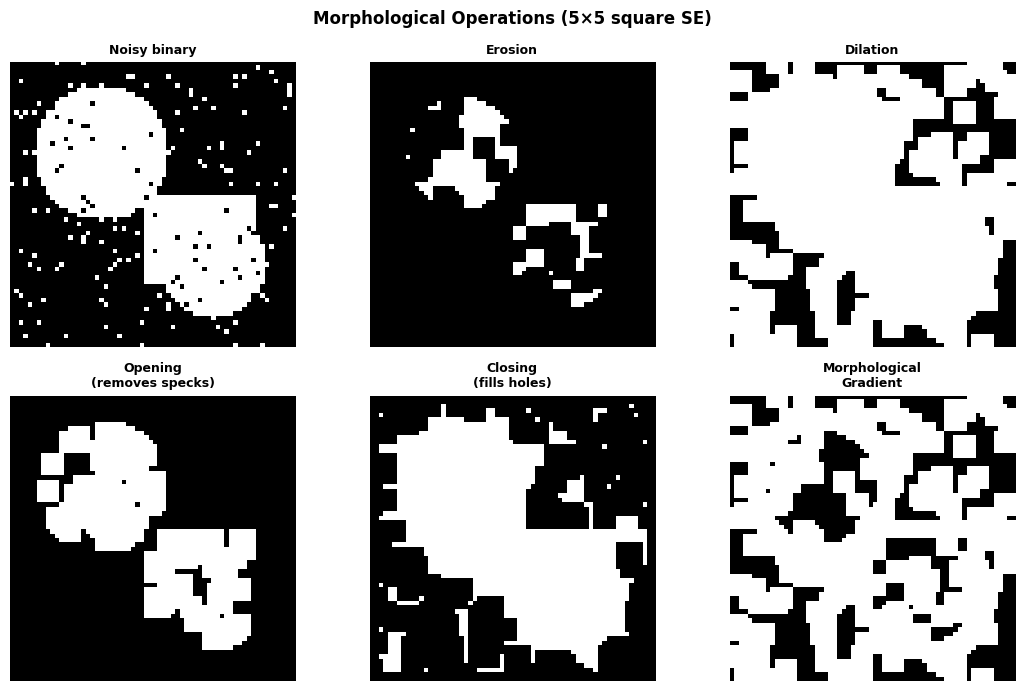

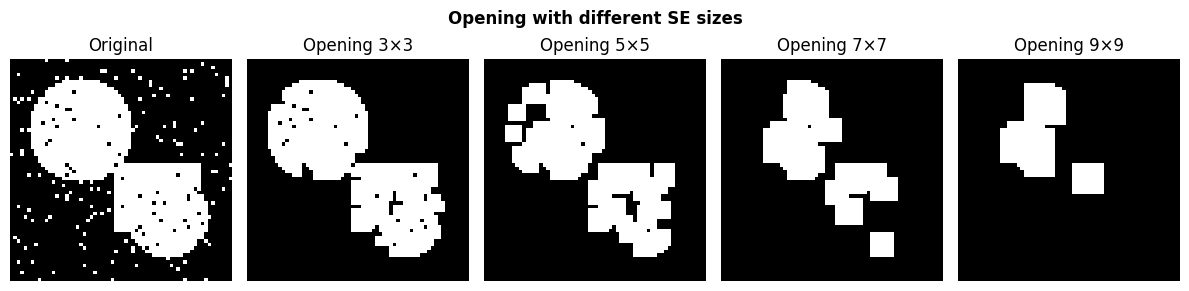

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def erode(img, B):
    H, W = img.shape; bH, bW = B.shape; pH, pW = bH//2, bW//2
    padded = np.pad(img, ((pH,pH),(pW,pW)), constant_values=0)
    out = np.zeros_like(img)
    for i in range(H):
        for j in range(W):
            region = padded[i:i+bH, j:j+bW]
            out[i,j] = 1 if np.all(region[B==1] == 1) else 0
    return out

def dilate(img, B):
    H, W = img.shape; bH, bW = B.shape; pH, pW = bH//2, bW//2
    padded = np.pad(img, ((pH,pH),(pW,pW)), constant_values=0)
    out = np.zeros_like(img)
    for i in range(H):
        for j in range(W):
            region = padded[i:i+bH, j:j+bW]
            out[i,j] = 1 if np.any(region[B==1] == 1) else 0
    return out

def opening(img, B):  return dilate(erode(img, B), B)
def closing(img, B):  return erode(dilate(img, B), B)

# ── Structuring elements ───────────────────────────────────────────────────────
B_sq   = np.ones((5,5),  dtype=np.uint8)      # square
B_disk = np.array([[0,1,0],[1,1,1],[0,1,0]],  dtype=np.uint8)  # 3×3 cross

# ── Noisy binary image with holes ─────────────────────────────────────────────
np.random.seed(3)
H, W = 64, 64
binary = np.zeros((H, W), dtype=np.uint8)
Y, X = np.ogrid[:H, :W]
binary[(X-20)**2+(Y-20)**2<=15**2] = 1
binary[(X-45)**2+(Y-45)**2<=12**2] = 1
binary[30:50, 30:55] = 1
# Add noise: random specks
noise_pos = np.random.rand(H,W) < 0.05
binary_noisy = np.clip(binary + noise_pos.astype(np.uint8), 0, 1)
# Punch holes
noise_neg = np.random.rand(H,W) < 0.04
binary_noisy = np.where(noise_neg, 0, binary_noisy).astype(np.uint8)

eroded  = erode(binary_noisy,  B_sq)
dilated = dilate(binary_noisy, B_sq)
opened  = opening(binary_noisy, B_sq)   # removes noise
closed  = closing(binary_noisy, B_sq)   # fills holes
morph_grad = dilated.astype(int) - eroded.astype(int)

results = [binary_noisy, eroded, dilated, opened, closed, morph_grad]
titles  = ["Noisy binary","Erosion","Dilation","Opening\n(removes specks)",
           "Closing\n(fills holes)","Morphological\nGradient"]
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for ax, r, t in zip(axes.flat, results, titles):
    ax.imshow(r, cmap="gray", vmin=0, vmax=1 if "Gradient" not in t else None)
    ax.set_title(t, fontsize=9, fontweight="bold"); ax.axis("off")
plt.suptitle("Morphological Operations (5×5 square SE)", fontweight="bold")
plt.tight_layout(); plt.show()

# ── Effect of structuring element size ───────────────────────────────────────
sizes = [3, 5, 7, 9]
fig, axes = plt.subplots(1, len(sizes)+1, figsize=(12, 3))
axes[0].imshow(binary_noisy, cmap="gray"); axes[0].set_title("Original"); axes[0].axis("off")
for ax, s in zip(axes[1:], sizes):
    B = np.ones((s,s), dtype=np.uint8)
    ax.imshow(opening(binary_noisy, B), cmap="gray")
    ax.set_title(f"Opening {s}×{s}"); ax.axis("off")
plt.suptitle("Opening with different SE sizes", fontweight="bold")
plt.tight_layout(); plt.show()

<a name="segmentation"></a>
## 5. Image Segmentation

Segmentation assigns a **label** to each pixel, partitioning the image into meaningful regions.

---

### Thresholding
Simplest method — separate foreground from background by a threshold $T$:
$$I_{\text{binary}}(i,j) = \begin{cases}1 & I(i,j) \geq T \\ 0 & \text{otherwise}\end{cases}$$

**Otsu's Method** — choose $T$ to maximise **between-class variance**:
$$\sigma_B^2(T) = w_0(T)\,w_1(T)\,[\mu_0(T)-\mu_1(T)]^2$$

where $w_k$ = class probability, $\mu_k$ = class mean.  
Equivalent to **minimising within-class variance** — runs in $O(L)$ after histogram.

---

### K-Means Segmentation
Cluster pixels by color (or position+color):
1. Initialise $K$ cluster centres $\mu_k$
2. Assign each pixel $\mathbf{x}$ to nearest centre: $c(\mathbf{x}) = \arg\min_k \|\mathbf{x}-\mu_k\|^2$
3. Update centres: $\mu_k = \frac{1}{|C_k|}\sum_{\mathbf{x}\in C_k}\mathbf{x}$
4. Repeat until convergence

**Objective:**
$$\mathcal{L} = \sum_{k=1}^{K}\sum_{\mathbf{x}\in C_k} \|\mathbf{x} - \mu_k\|^2$$

---

### Watershed
Treats the gradient magnitude as a topographic surface:
- **Catchment basins** fill up from local minima
- **Watershed lines** form where basins meet — these are the segment boundaries

Advantage: automatically finds boundaries, no need to specify $K$.

| Method | Params | Best for |
|--------|--------|----------|
| Thresholding | $T$ | Single-class, bimodal histograms |
| K-means | $K$ | Multi-color regions |
| Watershed | markers | Complex boundaries |
| Deep (U-Net) | millions | Arbitrary scenes |

Otsu threshold: 0.388


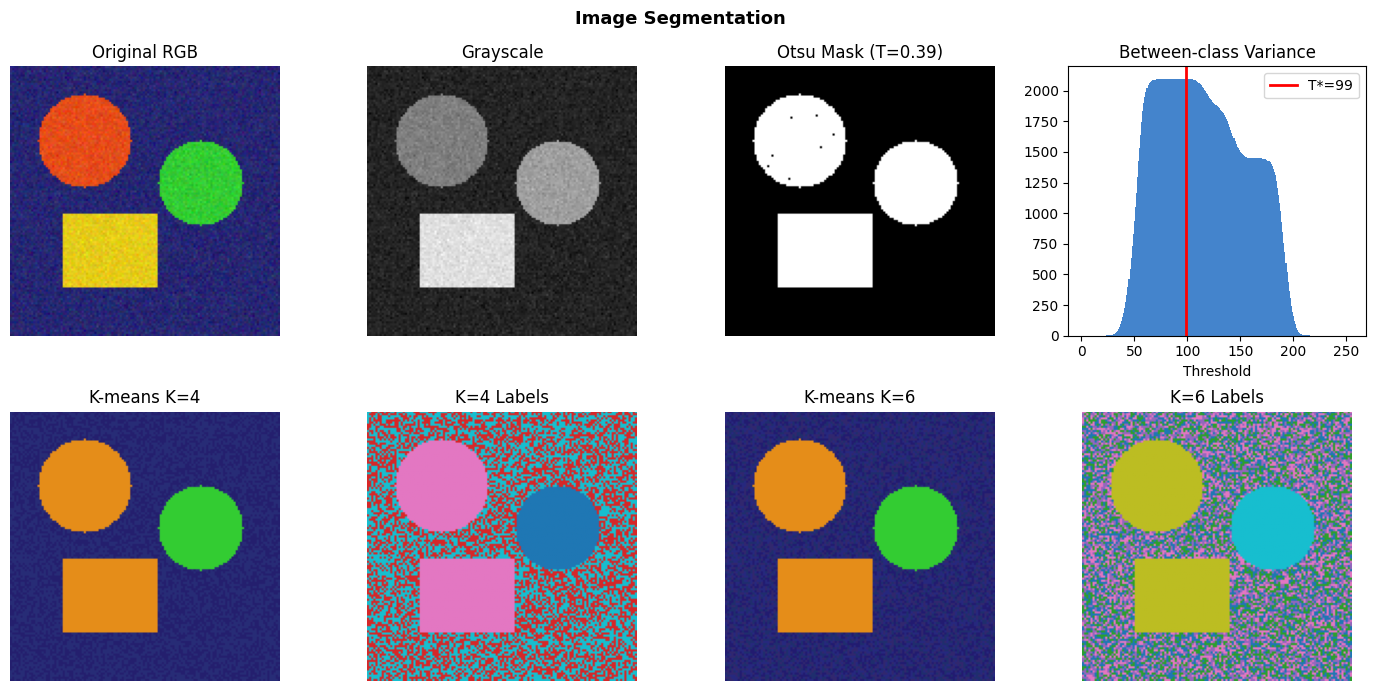

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ── Otsu's thresholding ───────────────────────────────────────────────────────
def otsu_threshold(img_gray):
    hist, _ = np.histogram((img_gray*255).astype(np.uint8), bins=256, range=(0,256))
    hist = hist / hist.sum()
    pix_vals = np.arange(256)
    best_t, best_var = 0, 0
    for t in range(1, 256):
        w0, w1 = hist[:t].sum(), hist[t:].sum()
        if w0 == 0 or w1 == 0: continue
        mu0 = (pix_vals[:t] * hist[:t]).sum() / w0
        mu1 = (pix_vals[t:] * hist[t:]).sum() / w1
        var = w0 * w1 * (mu0 - mu1)**2
        if var > best_var:
            best_var, best_t = var, t
    return best_t / 255.0

# ── K-Means segmentation ──────────────────────────────────────────────────────
def kmeans_segment(img, K=4, n_iter=20, seed=0):
    np.random.seed(seed)
    H, W, C = img.shape
    pixels = img.reshape(-1, C).astype(float)
    idx = np.random.choice(len(pixels), K, replace=False)
    centers = pixels[idx].copy()
    labels = np.zeros(len(pixels), dtype=int)
    for _ in range(n_iter):
        dists = np.array([np.sum((pixels - c)**2, axis=1) for c in centers])
        labels = np.argmin(dists, axis=0)
        for k in range(K):
            if (labels == k).sum() > 0:
                centers[k] = pixels[labels == k].mean(axis=0)
    segmented = centers[labels].reshape(H, W, C)
    return segmented.clip(0, 1), labels.reshape(H, W)

# ── Test image ────────────────────────────────────────────────────────────────
np.random.seed(5)
H, W = 128, 128
img = np.zeros((H, W, 3))
Y, X = np.ogrid[:H, :W]
img[:,:] = [0.15, 0.15, 0.45]         # dark blue background
img[(X-35)**2+(Y-35)**2<=22**2] = [0.9, 0.3, 0.1]  # red circle
img[(X-90)**2+(Y-55)**2<=20**2] = [0.2, 0.8, 0.2]  # green circle
img[70:105, 25:70]               = [0.9, 0.8, 0.1]  # yellow rectangle
img += 0.04*np.random.randn(H, W, 3); img = img.clip(0,1)

gray = 0.299*img[:,:,0] + 0.587*img[:,:,1] + 0.114*img[:,:,2]

# Otsu
T = otsu_threshold(gray)
otsu_mask = (gray >= T).astype(float)
print(f"Otsu threshold: {T:.3f}")

# K-means
seg_k4, labels_k4 = kmeans_segment(img, K=4)
seg_k6, labels_k6 = kmeans_segment(img, K=6)

# Otsu sweep — variance vs threshold
hist, _ = np.histogram((gray*255).astype(np.uint8), bins=256, range=(0,256))
hist    = hist / hist.sum()
pix_v   = np.arange(256)
variances = []
for t in range(1,256):
    w0  = hist[:t].sum(); w1 = hist[t:].sum()
    if w0==0 or w1==0: variances.append(0); continue
    mu0 = (pix_v[:t]*hist[:t]).sum()/w0
    mu1 = (pix_v[t:]*hist[t:]).sum()/w1
    variances.append(w0*w1*(mu0-mu1)**2)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes[0,0].imshow(img);              axes[0,0].set_title("Original RGB")
axes[0,1].imshow(gray, cmap="gray"); axes[0,1].set_title("Grayscale")
axes[0,2].imshow(otsu_mask, cmap="gray"); axes[0,2].set_title(f"Otsu Mask (T={T:.2f})")
axes[0,3].bar(range(1,256),variances,width=1,color="#1565C0",alpha=0.8)
axes[0,3].axvline(T*255, color="red", lw=2, label=f"T*={T*255:.0f}")
axes[0,3].set_title("Between-class Variance"); axes[0,3].legend(); axes[0,3].set_xlabel("Threshold")
axes[1,0].imshow(seg_k4);  axes[1,0].set_title("K-means K=4")
axes[1,1].imshow(labels_k4, cmap="tab10"); axes[1,1].set_title("K=4 Labels")
axes[1,2].imshow(seg_k6);  axes[1,2].set_title("K-means K=6")
axes[1,3].imshow(labels_k6, cmap="tab10"); axes[1,3].set_title("K=6 Labels")
for ax in axes.flat: ax.axis("off") if ax.get_title() != "Between-class Variance" else None
plt.suptitle("Image Segmentation", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()

<a name="features"></a>
## 6. Feature Detection & Matching

A good feature is **distinctive** (unique), **invariant** (stable under transformations), and **repeatable**.

---

### Harris Corner Detector
Analyse the image within a window $w(x,y)$ — a corner causes intensity change in **all** directions.

**Autocorrelation matrix (structure tensor):**
$$M = \sum_{x,y} w(x,y) \begin{bmatrix} I_x^2 & I_x I_y \\ I_x I_y & I_y^2 \end{bmatrix}$$

**Harris response:**
$$R = \det(M) - k\,[\text{tr}(M)]^2 = \lambda_1\lambda_2 - k(\lambda_1+\lambda_2)^2$$

| $R$ value | Interpretation |
|-----------|---------------|
| $R \gg 0$ | Corner |
| $R \ll 0$ | Edge |
| $\|R\| \approx 0$ | Flat region |

Typical $k \in [0.04, 0.06]$.

---

### SIFT (Scale-Invariant Feature Transform) — Overview
1. **DoG** keypoints at multiple scales (blob detector)
2. **Orientation assignment** from local gradient histogram (rotation invariance)
3. **128-D descriptor**: 4×4 spatial grid × 8-bin orientation histogram

**Scale invariance** from the Gaussian scale-space:  
$$L(x,y,\sigma) = G_\sigma * I(x,y)$$

### ORB (Oriented FAST + Rotated BRIEF)
- Fast keypoint detector (FAST) + rotation-invariant BRIEF descriptor
- Binary descriptor → Hamming distance matching
- Patent-free alternative to SIFT

---

### Feature Matching
Given descriptors $\mathbf{d}_i$ (image 1) and $\mathbf{d}_j$ (image 2):
- **Nearest neighbour (NN)**: match to closest descriptor
- **Ratio test** (Lowe): accept match only if $\frac{d_1}{d_2} < 0.75$ (avoids ambiguous matches)

Harris corners found: 8


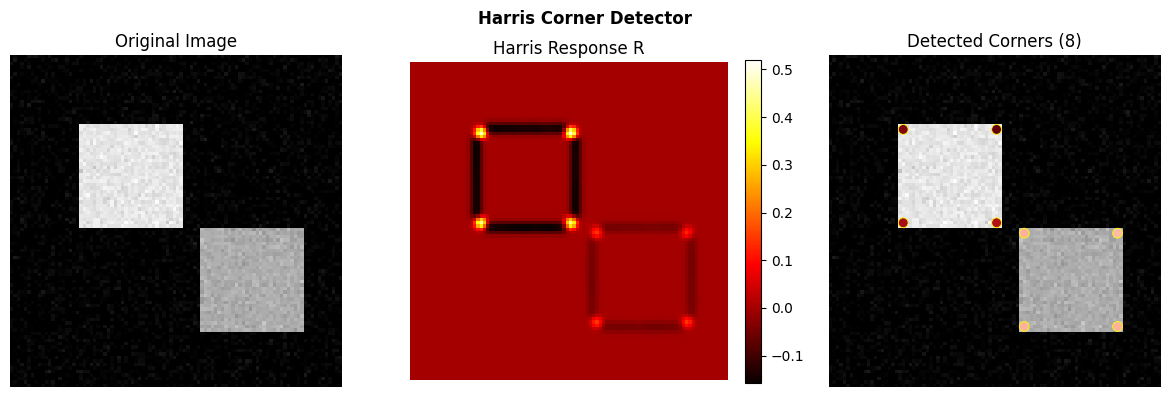

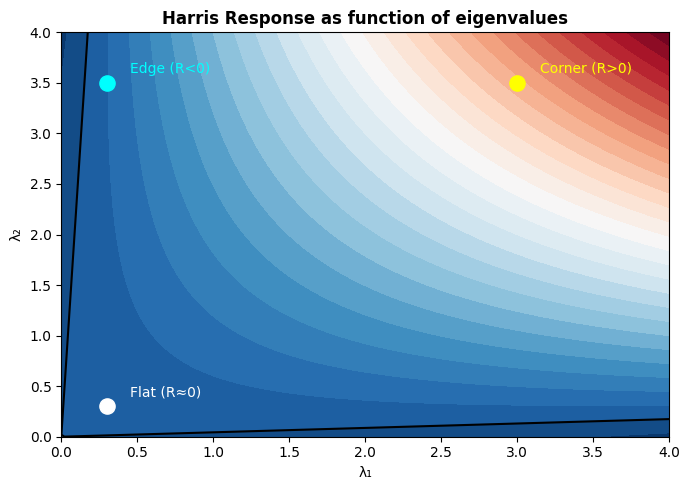

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def conv2d(image, kernel):
    H, W = image.shape; kH, kW = kernel.shape
    padded = np.pad(image, ((kH//2,kH//2),(kW//2,kW//2)), mode="reflect")
    out = np.zeros_like(image, dtype=float)
    for i in range(H):
        for j in range(W):
            out[i,j] = (padded[i:i+kH, j:j+kW] * kernel).sum()
    return out

def gaussian_kernel(size=5, sigma=1.0):
    ax = np.arange(-(size//2), size//2+1); xx,yy = np.meshgrid(ax,ax)
    k = np.exp(-(xx**2+yy**2)/(2*sigma**2)); return k/k.sum()

# ── Harris Corner Detector ────────────────────────────────────────────────────
def harris_corners(img, k=0.04, sigma=1.5, threshold=0.01, nms_size=9):
    blurred = conv2d(img, gaussian_kernel(5, sigma))
    Kx = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=float)
    Ky = Kx.T
    Ix = conv2d(blurred, Kx)
    Iy = conv2d(blurred, Ky)
    # Structure tensor components (smoothed)
    w = gaussian_kernel(5, sigma)
    Ixx = conv2d(Ix*Ix, w)
    Ixy = conv2d(Ix*Iy, w)
    Iyy = conv2d(Iy*Iy, w)
    det = Ixx*Iyy - Ixy**2
    tr  = Ixx + Iyy
    R   = det - k * tr**2
    # Threshold + NMS
    R_thresh = np.where(R > threshold * R.max(), R, 0)
    H, W = R.shape
    corners = []
    half = nms_size // 2
    for i in range(half, H-half):
        for j in range(half, W-half):
            patch = R_thresh[i-half:i+half+1, j-half:j+half+1]
            if R_thresh[i,j] == patch.max() and R_thresh[i,j] > 0:
                corners.append((i,j,R_thresh[i,j]))
    return R, corners

# ── Test image ────────────────────────────────────────────────────────────────
np.random.seed(8)
H, W = 96, 96
img = np.zeros((H, W))
img[20:50, 20:50] = 0.8   # square 1
img[50:80, 55:85] = 0.6   # square 2
img += 0.03 * np.random.randn(H, W); img = img.clip(0,1)

R, corners = harris_corners(img, threshold=0.01, nms_size=9)
cy = [c[0] for c in corners]; cx = [c[1] for c in corners]
print(f"Harris corners found: {len(corners)}")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img, cmap="gray"); axes[0].set_title("Original Image")
im = axes[1].imshow(R, cmap="hot"); axes[1].set_title("Harris Response R")
plt.colorbar(im, ax=axes[1], fraction=0.046)
axes[2].imshow(img, cmap="gray")
axes[2].scatter(cx, cy, c=[c[2] for c in corners], s=50, cmap="Reds",
                vmin=0, edgecolors="yellow", linewidths=0.6)
axes[2].set_title(f"Detected Corners ({len(corners)})")
for ax in axes: ax.axis("off")
plt.suptitle("Harris Corner Detector", fontweight="bold"); plt.tight_layout(); plt.show()

# ── Visualise eigenvalue interpretation ───────────────────────────────────────
K_vals = np.linspace(0, 5, 300)
flat_region = np.array([0.1, 0.1])  # both eigenvalues small
edge_region  = np.array([0.1, 3.0])
corner_region= np.array([2.5, 3.0])

fig, axes = plt.subplots(1, 1, figsize=(7, 5))
x = np.linspace(0, 4, 200); y = np.linspace(0, 4, 200)
lam1, lam2 = np.meshgrid(x, y)
R_map = lam1*lam2 - 0.04*(lam1+lam2)**2
axes.contourf(lam1, lam2, R_map, levels=30, cmap="RdBu_r")
axes.contour(lam1, lam2, R_map, levels=[0], colors="black", linewidths=1.5)
for (l1,l2,label,color) in [
    (0.3,0.3,"Flat (R≈0)","white"),
    (0.3,3.5,"Edge (R<0)","cyan"),
    (3.0,3.5,"Corner (R>0)","yellow")]:
    axes.scatter(l1,l2,s=120,c=color,zorder=5)
    axes.annotate(label,(l1,l2),fontsize=10,color=color,
                  xytext=(l1+0.15,l2+0.1))
axes.set_xlabel("λ₁"); axes.set_ylabel("λ₂")
axes.set_title("Harris Response as function of eigenvalues", fontweight="bold")
plt.tight_layout(); plt.show()

<a name="detection"></a>
## 7. Object Detection Fundamentals

Object detection outputs **bounding boxes** $(x, y, w, h)$ + class labels + confidence scores.

---

### Intersection over Union (IoU)
Measures overlap between predicted box $\hat{B}$ and ground-truth box $B$:

$$\text{IoU}(\hat{B}, B) = \frac{|\hat{B} \cap B|}{|\hat{B} \cup B|} = \frac{\text{intersection area}}{\text{union area}}$$

- IoU = 1 → perfect match
- IoU ≥ 0.5 → commonly used as "correct detection" threshold

---

### Non-Maximum Suppression (NMS)
Removes duplicate detections for the same object:
1. Sort boxes by confidence score (descending)
2. Keep highest-confidence box
3. Remove all boxes with IoU > threshold $\tau$ with kept box
4. Repeat until no boxes remain

---

### Anchor Boxes
YOLO/Faster R-CNN predicts **offsets** $(\delta x, \delta y, \delta w, \delta h)$ relative to pre-defined **anchor boxes**:

$$\hat{x} = \sigma(\delta x) + c_x, \quad \hat{y} = \sigma(\delta y) + c_y$$
$$\hat{w} = p_w e^{\delta w}, \quad \hat{h} = p_h e^{\delta h}$$

where $(c_x,c_y)$ is the grid cell offset and $(p_w,p_h)$ is the anchor prior.

---

### Detection Model Timeline

| Model | Year | Key idea |
|-------|------|---------|
| Sliding Window + HOG/SVM | ~2005 | Dense windows, hand-crafted features |
| R-CNN | 2014 | Selective search + CNN per region |
| Fast R-CNN | 2015 | Shared CNN features + ROI pooling |
| Faster R-CNN | 2015 | Region Proposal Network (RPN) |
| YOLO v1 | 2016 | Single-pass: grid predicts box+class |
| SSD | 2016 | Multi-scale anchors, single shot |
| YOLO v8 | 2023 | Anchor-free, real-time SOTA |

---

### Mean Average Precision (mAP)

$$\text{AP} = \int_0^1 P(R)\,dR \approx \sum_k P(k)\,\Delta R(k)$$
$$\text{mAP} = \frac{1}{|C|}\sum_{c \in C} \text{AP}_c$$

Box IoU values:
  Box 1: IoU=0.855  conf=0.95
  Box 2: IoU=0.471  conf=0.80
  Box 3: IoU=0.058  conf=0.60
  Box 4: IoU=0.740  conf=0.45


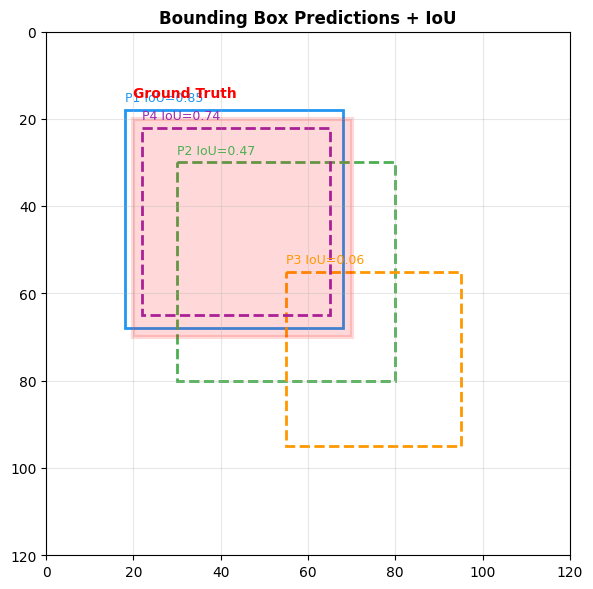


NMS kept boxes (IoU threshold=0.5): ['P1', 'P2', 'P3']

Simulated AP: 0.607


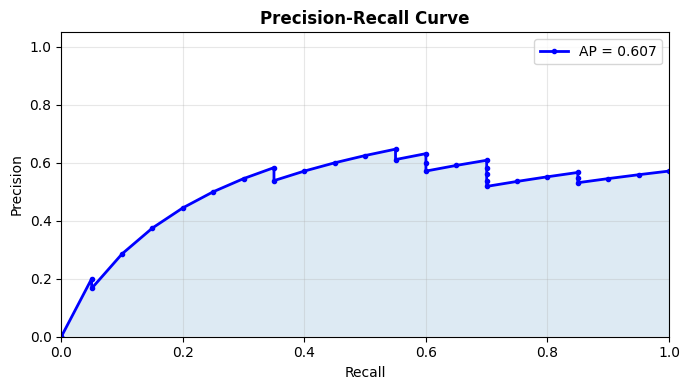

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ── IoU calculation ───────────────────────────────────────────────────────────
def iou(boxA, boxB):
    """boxA, boxB: [x1, y1, x2, y2]"""
    x1 = max(boxA[0], boxB[0]); y1 = max(boxA[1], boxB[1])
    x2 = min(boxA[2], boxB[2]); y2 = min(boxA[3], boxB[3])
    inter = max(0, x2-x1) * max(0, y2-y1)
    aA = (boxA[2]-boxA[0])*(boxA[3]-boxA[1])
    aB = (boxB[2]-boxB[0])*(boxB[3]-boxB[1])
    return inter / (aA + aB - inter + 1e-9)

gt  = [20, 20, 70, 70]
preds = [
    [18, 18, 68, 68],  # good overlap
    [30, 30, 80, 80],  # moderate
    [55, 55, 95, 95],  # poor
    [22, 22, 65, 65],  # good
]
confs = [0.95, 0.80, 0.60, 0.45]

print("Box IoU values:")
for i,(b,c) in enumerate(zip(preds,confs)):
    print(f"  Box {i+1}: IoU={iou(gt,b):.3f}  conf={c:.2f}")

# ── Visualise IoU ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.set_xlim(0,120); ax.set_ylim(0,120); ax.invert_yaxis()

colors = ["#2196F3","#4CAF50","#FF9800","#9C27B0"]
for i,(b,c,color) in enumerate(zip(preds,confs,colors)):
    x,y,x2,y2 = b; w,h = x2-x, y2-y
    rect = patches.Rectangle((x,y),w,h,lw=2, edgecolor=color, facecolor="none",
                               linestyle="--" if i>0 else "-")
    ax.add_patch(rect)
    ax.text(x, y-2, f"P{i+1} IoU={iou(gt,b):.2f}", color=color, fontsize=9)

# Ground truth
x,y,x2,y2 = gt; w,h=x2-x,y2-y
ax.add_patch(patches.Rectangle((x,y),w,h,lw=3,edgecolor="red",facecolor="red",alpha=0.15))
ax.text(x,y-5,"Ground Truth",color="red",fontsize=10,fontweight="bold")
ax.set_title("Bounding Box Predictions + IoU", fontweight="bold")
ax.set_aspect("equal"); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

# ── Non-Maximum Suppression ────────────────────────────────────────────────────
def nms_boxes(boxes, scores, iou_threshold=0.5):
    order   = np.argsort(-np.array(scores))
    keep    = []
    remaining = list(order)
    while remaining:
        idx = remaining.pop(0)
        keep.append(idx)
        remaining = [i for i in remaining
                     if iou(boxes[idx], boxes[i]) < iou_threshold]
    return keep

kept = nms_boxes(preds, confs, iou_threshold=0.5)
print(f"\nNMS kept boxes (IoU threshold=0.5): {[f'P{k+1}' for k in kept]}")

# ── Precision-Recall curve simulation ─────────────────────────────────────────
# Simulate AP for a detection scenario
np.random.seed(42)
N = 50; n_pos = 20
sorted_scores = np.sort(np.random.rand(N))[::-1]
tp_flags = (np.random.rand(N) < (0.7 - 0.4*np.arange(N)/N))  # decays with rank

cum_tp = np.cumsum(tp_flags)
cum_fp = np.cumsum(~tp_flags)
precision = cum_tp / (cum_tp + cum_fp)
recall    = cum_tp / n_pos

AP = np.trapz(precision, recall)
print(f"\nSimulated AP: {AP:.3f}")

plt.figure(figsize=(7, 4))
plt.plot(recall, precision, "b-o", ms=3, lw=2, label=f"AP = {AP:.3f}")
plt.fill_between(recall, precision, alpha=0.15)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curve", fontweight="bold")
plt.xlim(0,1); plt.ylim(0,1.05); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

<a name="video"></a>
## 8. Video Processing

Video = sequence of frames $\{I_1, I_2, \ldots, I_T\}$ @ fps (frames per second).

---

### Optical Flow
Optical flow $\mathbf{v}(x,y) = (u, v)$ is the apparent velocity of each pixel between frames.

**Brightness Constancy Assumption:**
$$I(x,y,t) = I(x+u,\,y+v,\,t+1)$$

Taylor expansion gives the **optical flow constraint equation**:
$$I_x u + I_y v + I_t = 0, \quad I_x = \frac{\partial I}{\partial x},\ I_y = \frac{\partial I}{\partial y},\ I_t = \frac{\partial I}{\partial t}$$

One equation, two unknowns → **aperture problem** (underdetermined).

---

### Lucas-Kanade Method
Assume flow is **constant in a local window** $\Omega$ of pixels:
$$\begin{bmatrix} \sum I_x^2 & \sum I_x I_y \\ \sum I_x I_y & \sum I_y^2 \end{bmatrix} \begin{bmatrix}u\\v\end{bmatrix} = -\begin{bmatrix}\sum I_x I_t \\ \sum I_y I_t\end{bmatrix}$$

$$A^\top A\,\mathbf{v} = A^\top \mathbf{b} \implies \mathbf{v} = (A^\top A)^{-1} A^\top \mathbf{b}$$

Works well when $A^\top A$ is invertible → i.e. at **corners** (same condition as Harris!).

---

### Background Subtraction
Estimate background model $\hat{I}$ (running average or GMM) and flag moving pixels:

$$F(i,j) = 1 \iff |I_t(i,j) - \hat{I}(i,j)| > \theta$$

**Running average:**
$$\hat{I}_t = \alpha\,I_t + (1-\alpha)\,\hat{I}_{t-1}$$

---

### Frame Differencing vs Optical Flow

| Method | Speed | Dense/Sparse | Handles large motion |
|--------|-------|-------------|---------------------|
| Frame difference | Very fast | Dense | Yes |
| Background subtraction | Fast | Dense | Yes |
| Lucas-Kanade | Fast | Sparse (keypoints) | With pyramid |
| Farneback | Medium | Dense | Partially |
| Deep flow (FlowNet) | Slow | Dense | Yes |

Computing optical flow between frame 0 and frame 1 …
Mean flow magnitude: 0.1805  |  Max: 9.7531


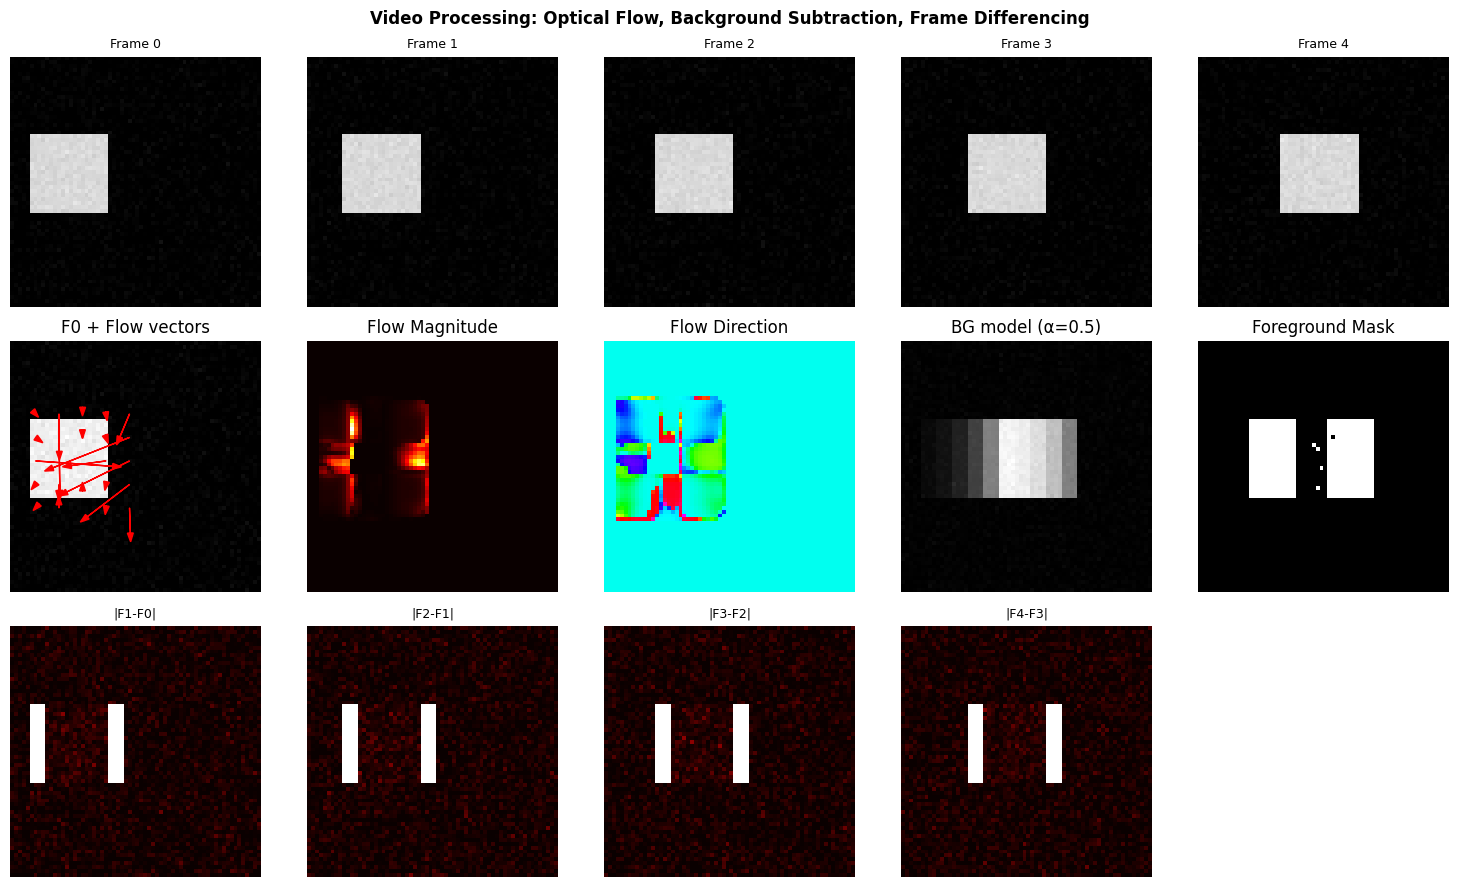

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian_kernel(size=5, sigma=1.0):
    ax = np.arange(-(size//2), size//2+1)
    xx, yy = np.meshgrid(ax, ax)
    k = np.exp(-(xx**2+yy**2)/(2*sigma**2)); return k/k.sum()

def conv2d(image, kernel):
    H, W = image.shape; kH, kW = kernel.shape
    padded = np.pad(image, ((kH//2,kH//2),(kW//2,kW//2)), mode="reflect")
    out = np.zeros_like(image, dtype=float)
    for i in range(H):
        for j in range(W):
            out[i,j] = (padded[i:i+kH, j:j+kW] * kernel).sum()
    return out

# ── Synthesise 5 video frames: moving rectangle ───────────────────────────────
H, W = 64, 64
n_frames = 6

def make_frame(t, speed=4):
    img = np.zeros((H, W))
    x0  = 5  + t * speed
    img[20:40, x0:x0+20] = 0.85
    img += 0.02 * np.random.randn(H, W)
    return img.clip(0, 1)

np.random.seed(12)
frames = [make_frame(t) for t in range(n_frames)]

# ── Lucas-Kanade Optical Flow (sparse, window-based) ─────────────────────────
def lucas_kanade(I1, I2, window=7):
    """Compute LK flow at every pixel using local window."""
    k_gauss = gaussian_kernel(5, 1.5)
    Kx = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=float)
    Ky = Kx.T
    I1b = conv2d(I1, k_gauss)
    I2b = conv2d(I2, k_gauss)
    Ix = conv2d(I1b, Kx)
    Iy = conv2d(I1b, Ky)
    It = I2b - I1b
    hw = window // 2
    U = np.zeros_like(I1)
    V = np.zeros_like(I1)
    for i in range(hw, H-hw):
        for j in range(hw, W-hw):
            ix = Ix[i-hw:i+hw+1, j-hw:j+hw+1].ravel()
            iy = Iy[i-hw:i+hw+1, j-hw:j+hw+1].ravel()
            it = It[i-hw:i+hw+1, j-hw:j+hw+1].ravel()
            A  = np.stack([ix, iy], axis=1)
            AtA = A.T @ A
            Atb = -A.T @ it
            det = AtA[0,0]*AtA[1,1] - AtA[0,1]**2
            if abs(det) > 1e-4:
                U[i,j] = (AtA[1,1]*Atb[0] - AtA[0,1]*Atb[1]) / det
                V[i,j] = (AtA[0,0]*Atb[1] - AtA[1,0]*Atb[0]) / det
    return U, V

print("Computing optical flow between frame 0 and frame 1 …")
U, V = lucas_kanade(frames[0], frames[1], window=7)
mag_flow = np.sqrt(U**2 + V**2)
print(f"Mean flow magnitude: {mag_flow.mean():.4f}  |  Max: {mag_flow.max():.4f}")

# ── Background subtraction ────────────────────────────────────────────────────
alpha = 0.5   # adaptation rate
bg = frames[0].copy()
fg_masks = []
for f in frames[1:]:
    fg_masks.append((np.abs(f - bg) > 0.15).astype(float))
    bg = alpha * f + (1 - alpha) * bg

# ── Frame differencing ────────────────────────────────────────────────────────
frame_diffs = [np.abs(frames[t+1] - frames[t]) for t in range(min(4, n_frames-1))]

# ── Plot all ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

# Row 1: frames
for t in range(5):
    axes[0,t].imshow(frames[t], cmap="gray", vmin=0, vmax=1)
    axes[0,t].set_title(f"Frame {t}", fontsize=9)
    axes[0,t].axis("off")

# Row 2: optical flow
axes[1,0].imshow(frames[0], cmap="gray"); axes[1,0].set_title("F0 + Flow vectors")
step = 6
for i in range(0, H, step):
    for j in range(0, W, step):
        mag = np.sqrt(U[i,j]**2 + V[i,j]**2)
        if mag > 0.05:
            axes[1,0].arrow(j, i, V[i,j]*5, U[i,j]*5, head_width=1.5,
                            color="red", length_includes_head=True)
axes[1,0].axis("off")
axes[1,1].imshow(mag_flow, cmap="hot"); axes[1,1].set_title("Flow Magnitude"); axes[1,1].axis("off")
axes[1,2].imshow(np.arctan2(V,U), cmap="hsv"); axes[1,2].set_title("Flow Direction"); axes[1,2].axis("off")
axes[1,3].imshow(bg, cmap="gray"); axes[1,3].set_title("BG model (α=0.5)"); axes[1,3].axis("off")
axes[1,4].imshow(fg_masks[-1], cmap="gray"); axes[1,4].set_title("Foreground Mask"); axes[1,4].axis("off")

# Row 3: frame differences
for t in range(4):
    axes[2,t].imshow(frame_diffs[t], cmap="hot", vmin=0, vmax=0.5)
    axes[2,t].set_title(f"|F{t+1}-F{t}|", fontsize=9); axes[2,t].axis("off")
axes[2,4].axis("off")

plt.suptitle("Video Processing: Optical Flow, Background Subtraction, Frame Differencing",
             fontweight="bold", fontsize=12)
plt.tight_layout(); plt.show()